## 0. CARGA DE DATOS Y VISTAZO GENERAL

In [1]:
# instalar via pip en un venv
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests

# estas ya vienen por defecto con python
import ssl
import io


# Tarda 2 minutos en cargar aprox.
response = requests.get(
    'https://datosabiertos.jcyl.es/web/jcyl/risp/es/medio-ambiente/calidad_aire_historico/1284212629698.csv',
    verify=False  # desactivamos verificacion SSL
)
calidad_aire = pd.read_csv(io.StringIO(response.text), sep=';')




c:\Users\Jordi\Documents\numpy\env\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'datosabiertos.jcyl.es'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\Jordi\Documents\numpy\env\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'analisis.datosabiertos.jcyl.es'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [2]:
print("s")

s


In [3]:
# Mostrar las primeras filas del DataFrame
print("*** HEAD ***")
calidad_aire.head(2)
print("="*100)

# Mostrar la estructura del DataFrame
print("*** INFO ***")
print(calidad_aire.info())
print("="*100)

# Mostrar un resumen estadístico de las variables numéricas
print("*** DESC ***")
print(calidad_aire.describe())
print("="*100)

*** HEAD ***
*** INFO ***
<class 'pandas.DataFrame'>
RangeIndex: 446014 entries, 0 to 446013
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Fecha         446014 non-null  str    
 1   CO (mg/m3)    101158 non-null  float64
 2   NO (ug/m3)    415030 non-null  float64
 3   NO2 (ug/m3)   413497 non-null  float64
 4   O3 (ug/m3)    275414 non-null  float64
 5   PM10 (ug/m3)  344579 non-null  float64
 6   PM25 (ug/m3)  53784 non-null   float64
 7   SO2 (ug/m3)   356277 non-null  float64
 8   Provincia     446014 non-null  str    
 9   Estación      446014 non-null  str    
 10  Latitud       445788 non-null  float64
 11  Longitud      445788 non-null  float64
 12  Posición      445788 non-null  str    
dtypes: float64(9), str(4)
memory usage: 44.2 MB
None
*** DESC ***
          CO (mg/m3)     NO (ug/m3)    NO2 (ug/m3)     O3 (ug/m3)  \
count  101158.000000  415030.000000  413497.000000  275414.000000   
mean     

In [4]:
calidad_aire.head(5)

,Fecha,CO (mg/m3),NO (ug/m3),NO2 (ug/m3),O3 (ug/m3),PM10 (ug/m3),PM25 (ug/m3),SO2 (ug/m3),Provincia,Estación,Latitud,Longitud,Posición
0,2020-12-31,NaN,7.0,22.0,45.0,3.0,NaN,9.0,León,C.T.L.R. - Cuadros,42.715556,-5.638889,"42.7155555556,-5.63888888889"
1,2020-12-31,NaN,NaN,NaN,NaN,6.0,NaN,4.0,León,Otero,42.564444,-6.781944,"42.5644444444,-6.78194444444"
2,2020-12-31,NaN,6.0,16.0,64.0,4.0,NaN,2.0,Soria,Soria,41.767222,-2.480556,"41.7672222222,-2.48055555556"
3,2020-12-31,NaN,1.0,1.0,53.0,1.0,1.0,3.0,Palencia,C.T.G. - Compuerto,42.849167,-4.835833,"42.8491666667,-4.83583333333"
4,2020-12-31,NaN,2.0,21.0,41.0,NaN,NaN,NaN,Valladolid,Michelin1,41.666389,-4.715000,"41.6663888889,-4.715"


## 1. DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

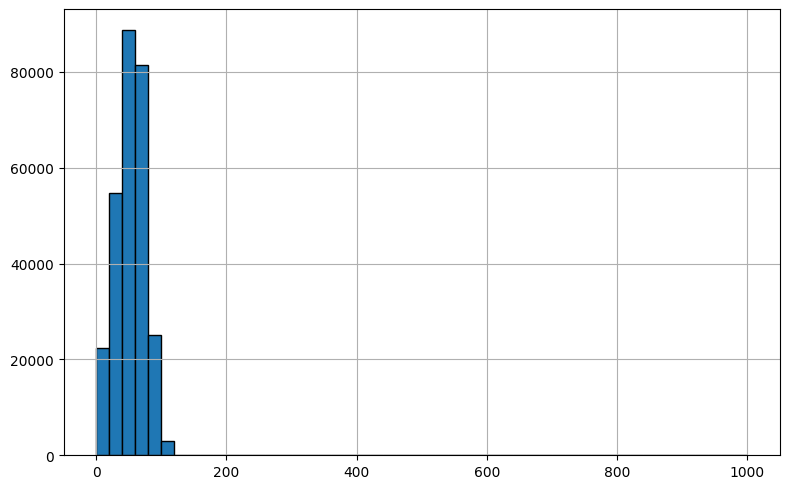

In [5]:
# 1_1
# CREA ESTE HISTOGRAMA PARA O3 (ug/m3)
plt.figure(figsize=(8, 5))
calidad_aire['O3 (ug/m3)'].hist(bins=50, edgecolor='black', range=(0, 1000))


plt.tight_layout()
plt.show()

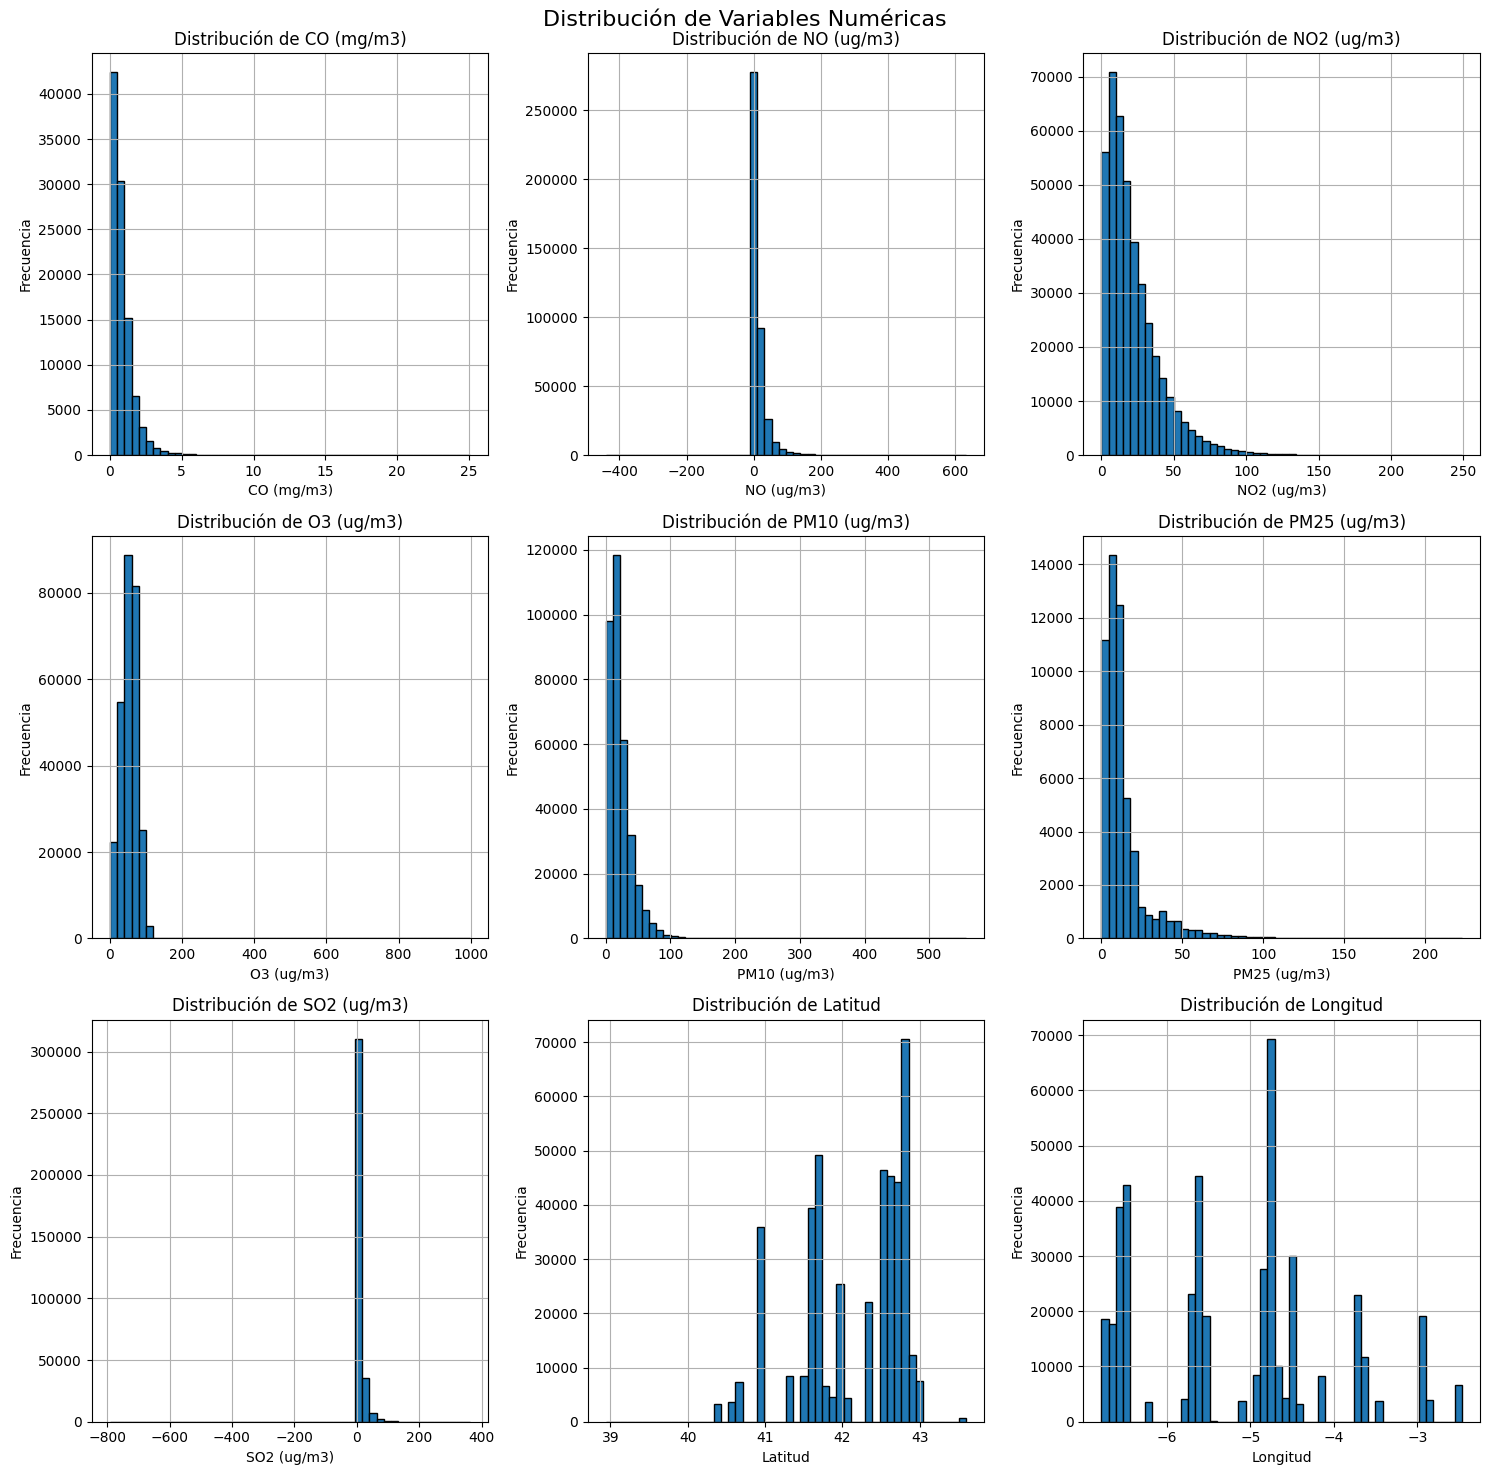

In [6]:
# 1_2
#  Seleccionar solo las columnas numéricas
columnas_numericas = calidad_aire.select_dtypes(include=[np.number]).columns

# Calcular el número de filas y columnas para el subplot
n = len(columnas_numericas)
nrows = 3
ncols = min(n, 3)

# Crear la figura y los subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Aplanar el array de ejes en caso de que sea 2D
axes = axes.flatten() if n > 3 else [axes]

# Crear histogramas para cada variable numérica
for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    calidad_aire[col].hist(ax=ax, bins=50, edgecolor='black')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

# Ocultar subplots vacíos si los hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 2. AJUSTE DE LAS VARIABLES CATEGÓRICAS

In [12]:
# 2_1
# Ajustar el tipo de la variable Fecha
calidad_aire['Fecha'] = pd.to_datetime(calidad_aire['Fecha'], errors='coerce')


# Ajustar el tipo de la variable Provincia
calidad_aire['Provincia'] = calidad_aire['Provincia'].astype('category')

# Ajustar el tipo de la variable Estación
calidad_aire['Estación'] = calidad_aire['Estación'].astype('category')
print(calidad_aire['Provincia'].unique())
print(calidad_aire.info())
calidad_aire.head()

['Palencia', 'Valladolid', 'Salamanca', 'Burgos', 'Soria', 'León', 'Zamora', 'Avila', 'Segovia', 'Madrid']
Categories (10, str): ['Avila', 'Burgos', 'León', 'Madrid', ..., 'Segovia', 'Soria', 'Valladolid', 'Zamora']
<class 'pandas.DataFrame'>
RangeIndex: 446014 entries, 0 to 446013
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Fecha         446014 non-null  datetime64[us]
 1   CO (mg/m3)    101158 non-null  float64       
 2   NO (ug/m3)    415030 non-null  float64       
 3   NO2 (ug/m3)   413497 non-null  float64       
 4   O3 (ug/m3)    275414 non-null  float64       
 5   PM10 (ug/m3)  344579 non-null  float64       
 6   PM25 (ug/m3)  53784 non-null   float64       
 7   SO2 (ug/m3)   356277 non-null  float64       
 8   Provincia     446014 non-null  category      
 9   Estación      446014 non-null  category      
 10  Latitud       445788 non-null  float64       
 11  Longitud      44

,Fecha,CO (mg/m3),NO (ug/m3),NO2 (ug/m3),O3 (ug/m3),PM10 (ug/m3),PM25 (ug/m3),SO2 (ug/m3),Provincia,Estación,Latitud,Longitud,Posición
0,2020-12-31,NaN,1.0,1.0,53.0,1.0,1.0,3.0,Palencia,C.T.G. - Compuerto,42.849167,-4.835833,"42.8491666667,-4.83583333333"
1,2020-12-31,NaN,5.0,3.0,57.0,4.0,NaN,3.0,Palencia,Hontoria 2 - Venta de Baños,41.948056,-4.465833,"41.9480555556,-4.46583333333"
2,2020-12-31,NaN,2.0,21.0,41.0,NaN,NaN,NaN,Valladolid,Michelin1,41.666389,-4.715000,"41.6663888889,-4.715"
3,2020-12-31,NaN,1.0,9.0,44.0,NaN,NaN,NaN,Valladolid,VALLADOLID SUR,41.611389,-4.772222,"41.6113888889,-4.77222222222"
4,2020-12-31,NaN,1.0,1.0,81.0,NaN,NaN,2.0,Salamanca,El Maillo,40.569444,-6.223889,"40.5694444444,-6.22388888889"


## 3. ANÁLISIS DE DATOS AUSENTES

In [23]:
# 3_1
print(calidad_aire.isna().sum())
print(f"NO NULOS: {calidad_aire.notna().sum().sum()}")
print(f"NULOS: {calidad_aire.isna().sum().sum()}")

Fecha                0
CO (mg/m3)      344856
NO (ug/m3)       30984
NO2 (ug/m3)      32517
O3 (ug/m3)      170600
PM10 (ug/m3)    101435
PM25 (ug/m3)    392230
SO2 (ug/m3)      89737
Provincia            0
Estación             0
Latitud            226
Longitud           226
Posición           226
dtype: int64
NO NULOS: 4635145
NULOS: 1163037


In [29]:
# 3_2
calidad_aire.isna().any()

# Porcentaje de nulos de cada columna
calidad_aire.isna().mean().round(2)*100

Fecha            0.0
CO (mg/m3)      77.0
NO (ug/m3)       7.0
NO2 (ug/m3)      7.0
O3 (ug/m3)      38.0
PM10 (ug/m3)    23.0
PM25 (ug/m3)    88.0
SO2 (ug/m3)     20.0
Provincia        0.0
Estación         0.0
Latitud          0.0
Longitud         0.0
Posición         0.0
dtype: float64

## TRATAMIENTO DE DATOS AUSENTES (ELIMINACIÓN E IMPUTACIÓN POR LA MEDIA)

In [ ]:
# 3_3
# Guardar dataset original
calidad_aire_original = calidad_aire.copy()

# Eliminación de las variables que presentan un % de NaN superior al 50%
calidad_aire = calidad_aire.loc[:, calidad_aire.isna().mean() < 0.5] # filtro de columna
print(f" Tras esta operación, contamos con {len(calidad_aire.columns)} columnas")

 Tras esta operación, contamos con 11 columnas


In [39]:
# 3_4
# Seleccionamos las variables numéricas con una máscara booleana
columnas_numericas = calidad_aire.select_dtypes(include=[np.number]).columns

# Calculamos la media para cada una de las variables numéricas sin tener en cuenta los NaN
columnas_media = calidad_aire[columnas_numericas].mean()
columnas_media

# Sustituimos los valores NaN por la media correspondiente a cada variable
calidad_aire[columnas_numericas] = calidad_aire[columnas_numericas].fillna(columnas_media)

calidad_aire.isna().mean()

Fecha           0.000000
NO (ug/m3)      0.000000
NO2 (ug/m3)     0.000000
O3 (ug/m3)      0.000000
PM10 (ug/m3)    0.000000
SO2 (ug/m3)     0.000000
Provincia       0.000000
Estación        0.000000
Latitud         0.000000
Longitud        0.000000
Posición        0.000507
dtype: float64

## 4. DETECCIÓN DE ATÍPICOS SOBRE VARIABLES NUMÉRICAS (HISTOGRAMA Y GRAFICO DE CAJAS Y BIGOTES)

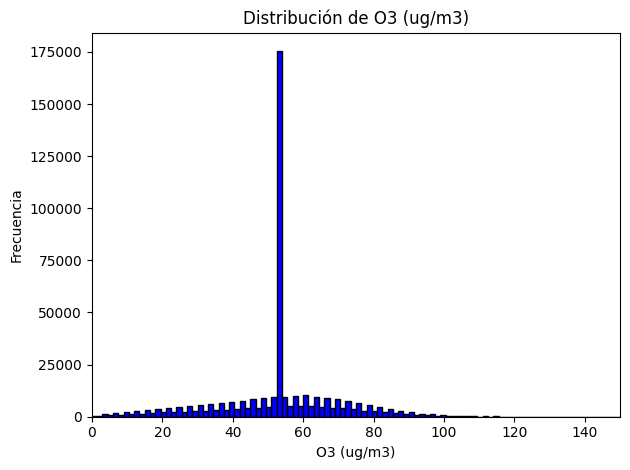

Estadísticas para O3:
Q1 - 1.5IQR = 31.50
Q1 = 48.00
Mediana = 52.62
Q3 = 59.00
Q3 + 1.5IQR = 75.50
Número de observaciones: 446014
Número de outliers: 91163


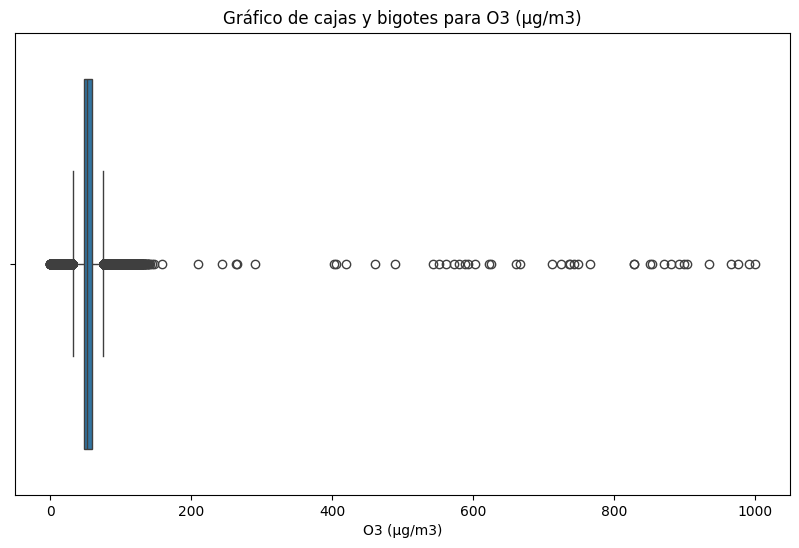

In [40]:
# 4_1
plt.hist(calidad_aire['O3 (ug/m3)'], bins=100, range=(0, 150), color='blue', edgecolor='black')
plt.title('Distribución de O3 (ug/m3)')
plt.xlabel('O3 (ug/m3)')
plt.ylabel('Frecuencia')
plt.xlim(0,150)
plt.tight_layout()
plt.show()


# Estadísticas necesarias para reproducir el gráfico de cajas y bigotes
Q1 = calidad_aire['O3 (ug/m3)'].quantile(0.25)
Q3 = calidad_aire['O3 (ug/m3)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Estadísticas para O3:")
print(f"Q1 - 1.5IQR = {lower_bound:.2f}")
print(f"Q1 = {Q1:.2f}")
print(f"Mediana = {calidad_aire['O3 (ug/m3)'].median():.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"Q3 + 1.5IQR = {upper_bound:.2f}")
print(f"Número de observaciones: {len(calidad_aire['O3 (ug/m3)'])}")
print(f"Número de outliers: {sum((calidad_aire['O3 (ug/m3)'] < lower_bound) | (calidad_aire['O3 (ug/m3)'] > upper_bound))}")

# Construcción del gráfico de cajas y bigotes
plt.figure(figsize=(10, 6))
sns.boxplot(x=calidad_aire['O3 (ug/m3)'])
plt.title('Gráfico de cajas y bigotes para O3 (µg/m3)')
plt.xlabel('O3 (µg/m3)')
plt.show()


## DETECCIÓN DE ATÍPICOS SOBRE VARIABLES CATEGÓRICAS

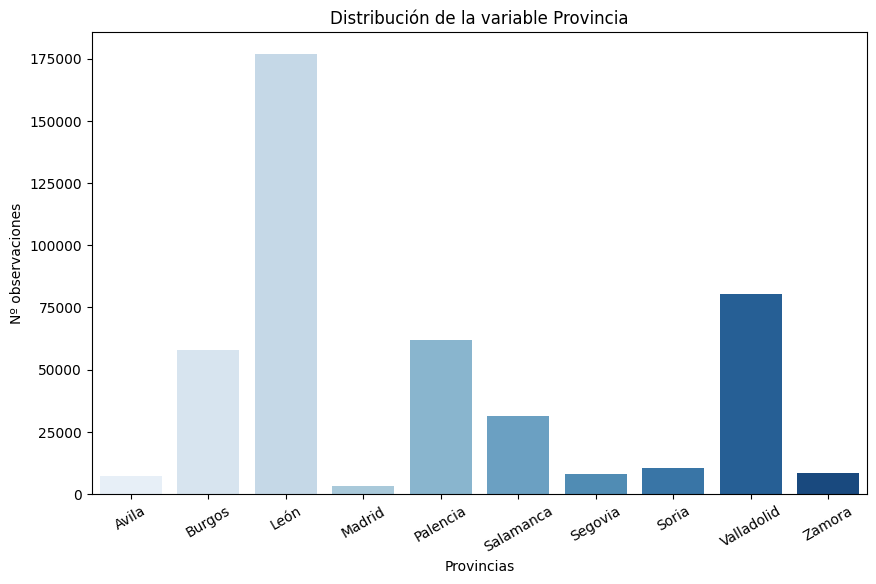

In [ ]:
# 4_2
# Número de categorías que presenta la variable Provincia
categoria_counts = calidad_aire['Provincia'].value_counts()

# Construcción del gráfico de barras para la variable Provincia
plt.figure(figsize=(10, 6))
sns.barplot(x=categoria_counts.index, y=categoria_counts.values, palette='Blues', hue=categoria_counts.index, legend=False)
plt.xlabel('Provincias')
plt.ylabel('Nº observaciones')
plt.xticks(rotation=30)
plt.title('Distribución de la variable Provincia')
plt.show()


## TRATAMIENTO DE VALORES ATÍPICOS EN VARIABLES NUMÉRICAS

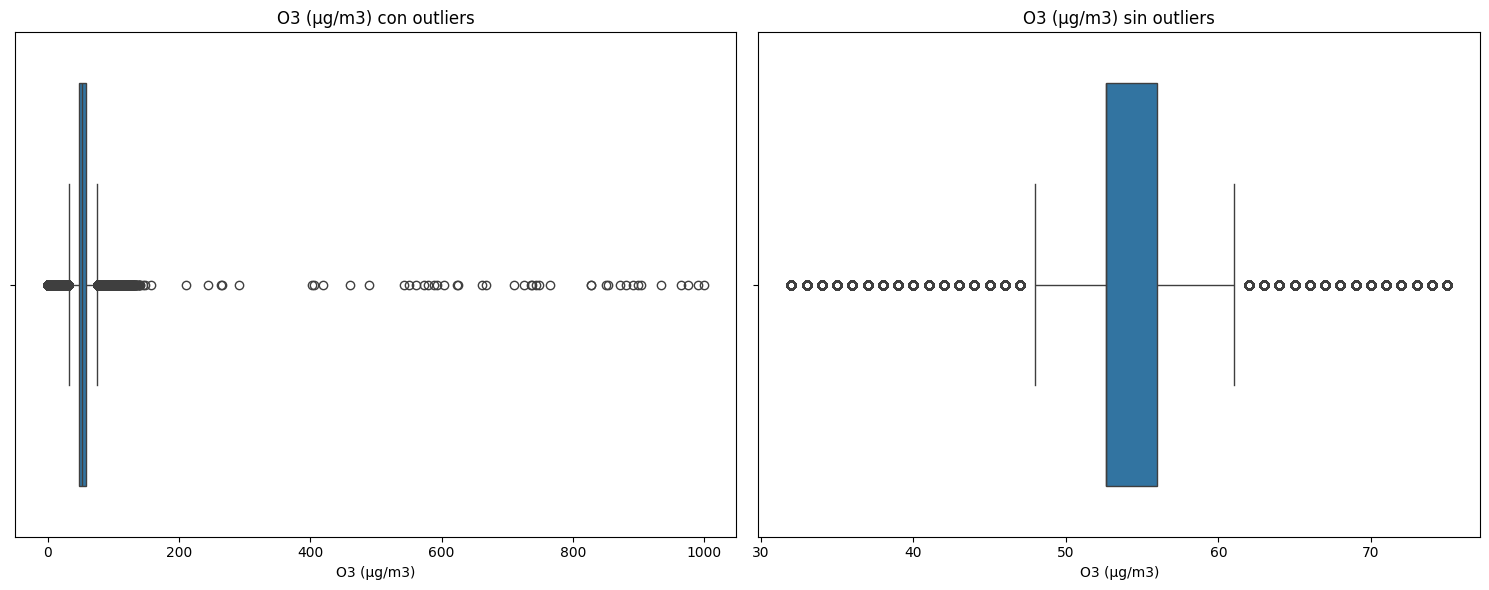

In [42]:
# Se genera una nueva tabla que no contiene los valores identificados como atípicos
mascara_o3 = (calidad_aire['O3 (ug/m3)'] > lower_bound) & (calidad_aire['O3 (ug/m3)'] < upper_bound)
calidad_aire_NoOut = calidad_aire[mascara_o3]

# Construcción de los gráficos de cajas y bigotes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x=calidad_aire['O3 (ug/m3)'], ax=ax1)
ax1.set_title('O3 (µg/m3) con outliers')
ax1.set_xlabel('O3 (µg/m3)')

sns.boxplot(x=calidad_aire_NoOut['O3 (ug/m3)'], ax=ax2)
ax2.set_title('O3 (µg/m3) sin outliers')
ax2.set_xlabel('O3 (µg/m3)')

plt.tight_layout()
plt.show()


## TRATAMIENTO DE VALORES ATÍPICOS EN VARIABLES CATEGÓRICAS

In [44]:
# Creamos una copia explícita del DataFrame excluyendo las filas de Madrid
mascara_madrid = calidad_aire['Provincia'] != 'Madrid'
calidad_aire_SM = calidad_aire[mascara_madrid].copy()

# Eliminamos las categorías no utilizadas
calidad_aire_SM['Provincia'] = calidad_aire_SM['Provincia'].astype('category').cat.remove_unused_categories()

# Verificamos la eliminación de la categoría "Madrid"
print(calidad_aire_SM['Provincia'].cat.categories)

Index(['Avila', 'Burgos', 'León', 'Palencia', 'Salamanca', 'Segovia', 'Soria',
       'Valladolid', 'Zamora'],
      dtype='str')


## 5. ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES

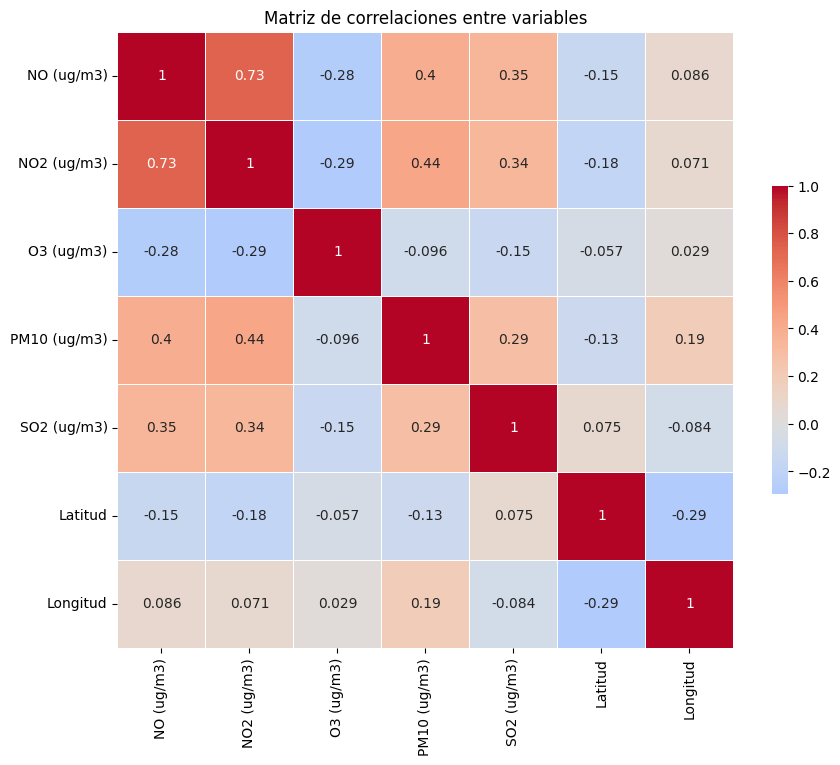

In [45]:
#5_1

# Calculamos la matriz de coeficientes de correlación entre las variables numéricas
variables_numericas = calidad_aire.select_dtypes(include=[np.number])
correlacion = variables_numericas.corr()

# Configuración del gráfico de correlación
plt.figure(figsize=(10, 8))

# Gráfico de correlaciones utilizando un mapa de calor
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Matriz de correlaciones entre variables')
plt.show()


## EDA AUTOMÁTICO

In [ ]:
# FALTA